# Lecture 5: The Phillips Curve and the AS Curve

**Macroeconomics B -- Chapter 18**

By the end of this notebook you will be able to:
1. Compute and plot year-on-year HICP inflation for Denmark and the United States.
2. Construct a Danish Phillips-curve scatter in acceleration form.
3. Simulate the short-run AS curve under static and anchored expectations.
4. Vary the AS slope and interpret the output cost of disinflation.

**Table of contents**<a id='toc0_'></a>
- 1. [Notebook map and calibration](#toc1_)
- 2. [Recent Inflation: Denmark and the United States](#toc2_)
- 3. [Phillips Curve for Denmark: Before and After 2020](#toc3_)
- 4. [AS Curve Simulation: Anchored vs Static Expectations](#toc4_)
- 5. [Sensitivity to the Slope Parameter $\gamma$](#toc5_)
- 6. [Summary](#toc6_)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lecture_05_notebook_utils import fetch_eurostat, simulate_as

# Global plot settings (matches reference course style)
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black',
                     'grid.alpha': 0.25, 'grid.linestyle': '--'})
plt.rcParams.update({'font.size': 12})

# Reproducibility
rng = np.random.default_rng(2025)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## 1. <a id='toc1_'></a>[Notebook map and calibration](#toc0_)

| Notebook section | Main idea |
|---|---|
| 2. Recent inflation | Use live HICP-comparable data to motivate why the Phillips curve matters again. |
| 3. Danish Phillips scatter | Estimate the slope in acceleration form before and after 2020. |
| 4. AS simulation | Compare inflation persistence under static and anchored expectations. |
| 5. Slope sensitivity | Connect a flatter AS curve to a larger output cost of disinflation. |

The parameter values are teaching calibrations. They are chosen to make the mechanisms visible in a graph, not to estimate Denmark or the United States structurally.

## 2. <a id='toc2_'></a>[Recent Inflation: Denmark and the United States](#toc0_)

You first look at how YoY HICP inflation has evolved since 2019 in Denmark and the United States. The 2021-2023 inflation surge is the empirical motivation for revisiting the Phillips curve: a plain unemployment-inflation trade-off cannot explain why both economies saw very high inflation while unemployment evolved differently.

Fetching inflation series:


  Denmark: Jan 2019 to Dec 2025, 84 obs
  United States: Jan 2019 to Dec 2024, 72 obs


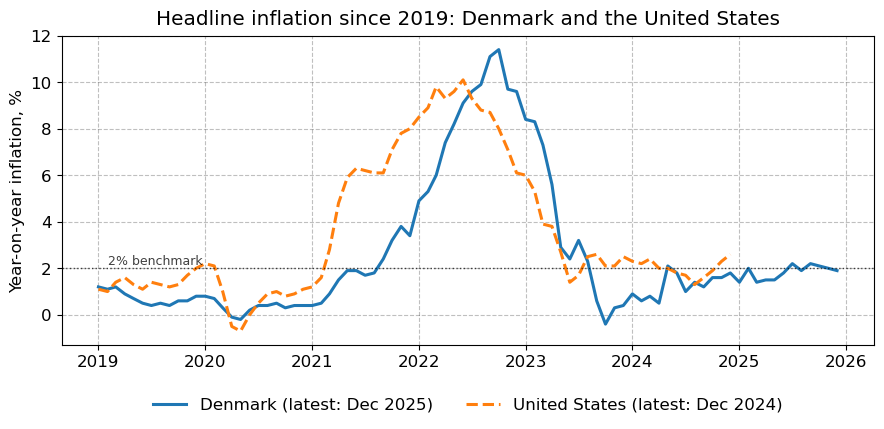


DK peak: 11.40% in Oct 2022
US peak: 10.10% in Jun 2022


In [2]:
print('Fetching inflation series:')
dk_pi = fetch_eurostat('prc_hicp_manr', geo='DK', coicop='CP00')
us_pi = fetch_eurostat('ei_cphi_m', geo='US', unit='RT12', indic='TOTAL')

start = '2019-01'
dk_pi = dk_pi[dk_pi.index >= start]
us_pi = us_pi[us_pi.index >= start]

print(f"  Denmark: {dk_pi.index[0]:%b %Y} to {dk_pi.index[-1]:%b %Y}, {len(dk_pi)} obs")
print(f"  United States: {us_pi.index[0]:%b %Y} to {us_pi.index[-1]:%b %Y}, {len(us_pi)} obs")

fig = plt.figure(figsize=(9, 4.5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(dk_pi.index, dk_pi.values, color=colors[0], lw=2.2,
        label=f'Denmark (latest: {dk_pi.index[-1]:%b %Y})')
ax.plot(us_pi.index, us_pi.values, color=colors[1], lw=2.2, ls='--',
        label=f'United States (latest: {us_pi.index[-1]:%b %Y})')
ax.axhline(2.0, color='black', lw=1, ls=':', alpha=0.7)
ax.text(pd.Timestamp('2019-02'), 2.15, '2% benchmark',
        fontsize=9, color='black', alpha=0.75)

ax.set_title('Headline inflation since 2019: Denmark and the United States',
             pad=8)
ax.set_xlabel('')
ax.set_ylabel('Year-on-year inflation, %')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=2, frameon=False)

fig.tight_layout()
fig.savefig('figs/inflation_dk_us_recent.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nDK peak: {dk_pi.max():.2f}% in {dk_pi.idxmax():%b %Y}")
print(f"US peak: {us_pi.max():.2f}% in {us_pi.idxmax():%b %Y}")

Both series show a sharp inflation spike followed by disinflation. The central question is whether this came mainly from demand pressure, supply shocks, expectations, or a mix of all three.

### Try it yourself

Change `start` to `'2021-01'` and rerun the cell. Does the disinflation phase look more similar or less similar across Denmark and the United States?

## 3. <a id='toc3_'></a>[Phillips Curve for Denmark: Before and After 2020](#toc0_)

You now construct a Phillips-curve scatter for Denmark in acceleration form:
$$\Delta\pi_t = \kappa (u_t - \bar u) + \text{shocks}.$$
Under static expectations, this comes from $\pi_t^e = \pi_{t-1}$ and the expectations-augmented Phillips curve. You compare the slope before March 2020 and after March 2020 to see how the empirical relationship changed around the COVID and energy-price period.

Fetching Danish Phillips-curve series:


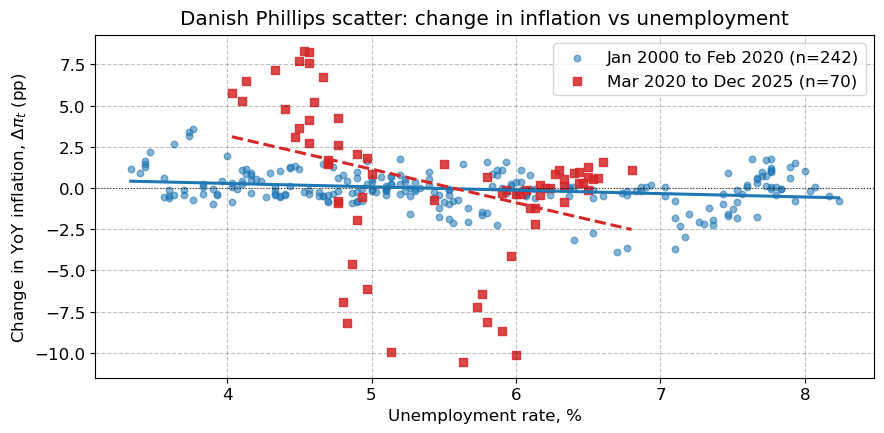


Fitted slope (pre-2020):  kappa_hat = -0.206
Fitted slope (post-2020): kappa_hat = -2.035


In [3]:
print('Fetching Danish Phillips-curve series:')
dk_u = fetch_eurostat('une_rt_m', geo='DK', sex='T', age='TOTAL',
                      s_adj='SA', unit='PC_ACT')
dk_pi_full = fetch_eurostat('prc_hicp_manr', geo='DK', coicop='CP00')

df = pd.DataFrame({'pi': dk_pi_full, 'u': dk_u}).dropna()
df = df[df.index >= '1999-01']

df['pi_smooth'] = df['pi'].rolling(3, min_periods=1).mean()
df['u_smooth'] = df['u'].rolling(3, min_periods=1).mean()
df['dpi'] = df['pi_smooth'].diff(12)
df = df.dropna()

pre = df[df.index < '2020-03']
post = df[df.index >= '2020-03']

fig = plt.figure(figsize=(9, 4.5))
ax = fig.add_subplot(1, 1, 1)

ax.scatter(pre['u_smooth'], pre['dpi'], color=colors[0], s=22,
           alpha=0.55, label=f'Jan 2000 to Feb 2020 (n={len(pre)})')
ax.scatter(post['u_smooth'], post['dpi'], color=colors[3], s=28,
           alpha=0.85, marker='s',
           label=f'Mar 2020 to {df.index[-1]:%b %Y} (n={len(post)})')
ax.axhline(0, color='black', lw=0.8, ls=':', alpha=0.7)

slopes = {}
for sample, color, style, name in [(pre, colors[0], '-', 'pre'),
                                   (post, colors[3], '--', 'post')]:
    coef = np.polyfit(sample['u_smooth'], sample['dpi'], 1)
    slopes[name] = coef[0]
    u_grid = np.linspace(sample['u_smooth'].min(),
                         sample['u_smooth'].max(), 50)
    ax.plot(u_grid, np.polyval(coef, u_grid),
            color=color, lw=2.2, ls=style)

ax.set_title('Danish Phillips scatter: change in inflation vs unemployment',
             pad=8)
ax.set_xlabel('Unemployment rate, %')
ax.set_ylabel(r'Change in YoY inflation, $\Delta \pi_t$ (pp)')
ax.legend(loc='upper right')

fig.tight_layout()
fig.savefig('figs/phillips_dk_recent.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nFitted slope (pre-2020):  kappa_hat = {slopes['pre']:.3f}")
print(f"Fitted slope (post-2020): kappa_hat = {slopes['post']:.3f}")

The post-2020 cloud spreads vertically much more than the pre-2020 cloud. That is exactly what the AS equation predicts when supply shocks are large: inflation moves for reasons that are not captured by unemployment alone.

**Check your understanding**

**Question:** Looking at the Danish post-2020 scatter, the cloud spreads vertically much more than before 2020. Which explanation fits the AS equation best?

(A) The slope on unemployment became infinitely large.  
(B) Supply shocks were unusually large in this period.  
(C) The natural rate disappeared.  
(D) Unemployment stopped mattering mechanically.

### Try it yourself

Change the split date from `'2020-03'` to `'2021-01'`. Do the fitted slopes or the visual message change much?

## 4. <a id='toc4_'></a>[AS Curve Simulation: Anchored vs Static Expectations](#toc0_)

You now simulate the short-run AS curve
$$\pi_t = \pi_t^e + \gamma (y_t - \bar y) + s_t$$
under two regimes for expectations:

- **Static:** $\pi_t^e = \pi_{t-1}$, so today's inflation feeds directly into tomorrow's expectations.
- **Anchored:** $\pi_t^e = \pi^*$, so expectations stay close to the target.

The experiment isolates expectations by holding the output gap at zero and using a one-period supply shock.

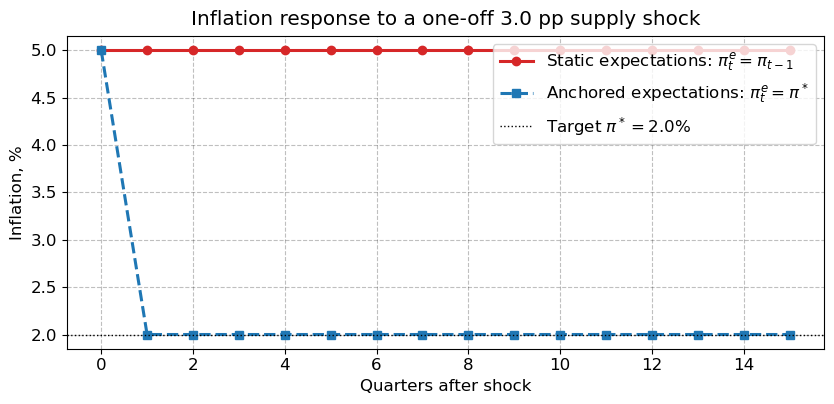

In [4]:
par = {
    'gamma':  0.4,
    'pi_star': 2.0,
    'shock':   3.0,
    'T':       16,
    'y_gap':   0.0,
}

pi_static = simulate_as(par, 'static')
pi_anchored = simulate_as(par, 'anchored')
quarters = np.arange(par['T'])

fig = plt.figure(figsize=(8.5, 4.2))
ax = fig.add_subplot(1, 1, 1)

ax.plot(quarters, pi_static, color=colors[3], lw=2.2, marker='o',
        label=r'Static expectations: $\pi^e_t = \pi_{t-1}$')
ax.plot(quarters, pi_anchored, color=colors[0], lw=2.2, ls='--', marker='s',
        label=r'Anchored expectations: $\pi^e_t = \pi^*$')
ax.axhline(par['pi_star'], color='black', lw=1, ls=':',
           label=fr"Target $\pi^* = {par['pi_star']}$%")

ax.set_title(f"Inflation response to a one-off {par['shock']} pp supply shock",
             pad=8)
ax.set_xlabel('Quarters after shock')
ax.set_ylabel('Inflation, %')
ax.legend(loc='upper right')

fig.tight_layout()
plt.show()

With static expectations, the shock becomes persistent because today's inflation becomes tomorrow's expected inflation. With anchored expectations, the same shock fades quickly because expected inflation stays near the target.

### Try it yourself

Set `par['y_gap'] = -1.0` and rerun the cell. How large does the negative output gap need to be to offset a 3 percentage point supply shock when $\gamma = 0.4$?

## 5. <a id='toc5_'></a>[Sensitivity to the Slope Parameter $\gamma$](#toc0_)

A central empirical question is how steep the short-run AS curve actually is. A flatter $\gamma$ means slack moves inflation less; a steeper $\gamma$ makes inflation more sensitive to the output gap.

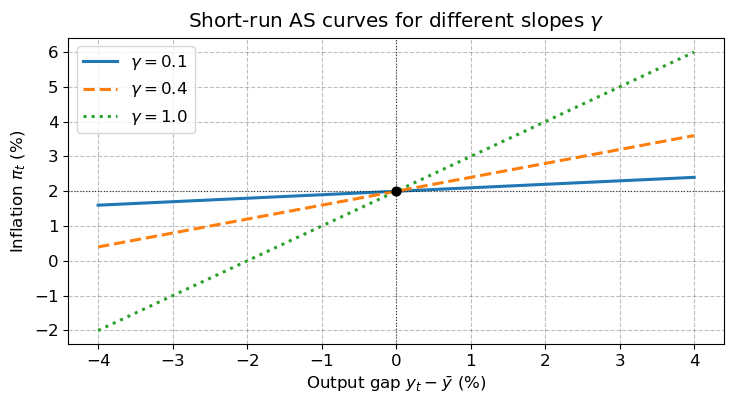

In [5]:
y_gap = np.linspace(-4, 4, 200)
gammas = [0.1, 0.4, 1.0]
line_styles = ['-', '--', ':']
pi_e = 2.0

fig = plt.figure(figsize=(7.5, 4.2))
ax = fig.add_subplot(1, 1, 1)

for g, c, ls in zip(gammas, colors[:3], line_styles):
    ax.plot(y_gap, pi_e + g * y_gap, lw=2.2, ls=ls, color=c,
            label=fr'$\gamma = {g}$')

ax.axhline(pi_e, color='black', lw=0.8, ls=':', alpha=0.7)
ax.axvline(0, color='black', lw=0.8, ls=':', alpha=0.7)
ax.scatter([0], [pi_e], color='black', s=40, zorder=5)

ax.set_title(r'Short-run AS curves for different slopes $\gamma$', pad=8)
ax.set_xlabel(r'Output gap $y_t - \bar y$ (%)')
ax.set_ylabel(r'Inflation $\pi_t$ (%)')
ax.legend(loc='upper left')

fig.tight_layout()
plt.show()

The flatter the AS curve, the less inflation falls for a given negative output gap. This is why a low value of $\gamma$ raises the output cost of disinflation after a supply shock.

## 6. <a id='toc6_'></a>[Summary](#toc0_)

| Equation | Meaning |
|---|---|
| $\pi = \beta - \alpha u$ | Simple reduced-form Phillips curve |
| $\pi = \pi^e + \mu - \alpha u$ | Expectations-augmented Phillips curve |
| $\bar u = \mu / \alpha$ | Natural rate of unemployment |
| $\pi - \pi^e = -\alpha(u - \bar u)$ | Only deviations from $\bar u$ create inflation surprises |
| $u_t - \bar u \approx -\lambda(y_t - \bar y)$ | Okun-style link between unemployment and output |
| $\pi_t = \pi_t^e + \gamma(y_t - \bar y) + s_t$ | Short-run AS curve, with $\gamma \equiv \alpha\lambda$ |
| $\Delta\pi_t = \kappa(u_t - \bar u) + \text{shocks}$ | Acceleration form used in the Danish scatter |

**Key empirical takeaways from the live data above:**
- Denmark and the United States both went through a sharp inflation spike in 2021-2023 followed by disinflation.
- The Danish post-2020 Phillips scatter shows large vertical dispersion at modest unemployment levels, consistent with large supply shocks.
- Anchored expectations make a one-off supply shock less persistent.

**Socrative room:** MACROECONOMICSB